1. Data Loading & Inspection

In [ ]:
import pandas as pd
#from google.colab import drive
#drive.mount('/content/drive')
# df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/q1_heart_disease.csv')

df = pd.read_csv('../data/q1_heart_disease.csv')
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(800, 12)
age                  int64
sex                  int64
chest_pain_type     object
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg         object
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope            object
heart_disease        int64
dtype: object
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


2. Exploratory Data Analysis

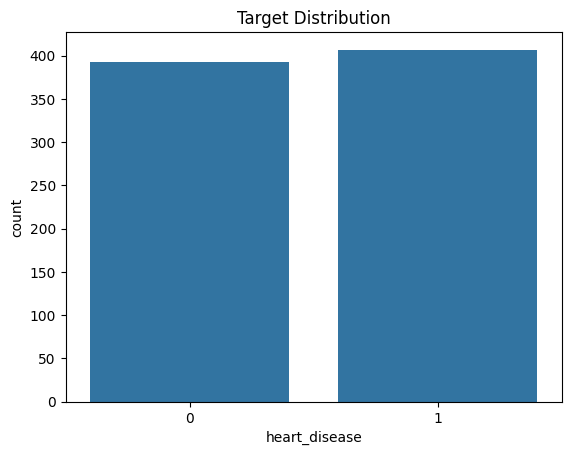

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='heart_disease', data=df)
plt.title("Target Distribution")
plt.show()

MARKDOWN -
* Dataset is (balanced / slightly imbalanced — check actual output)
* Balanced → good for model learning



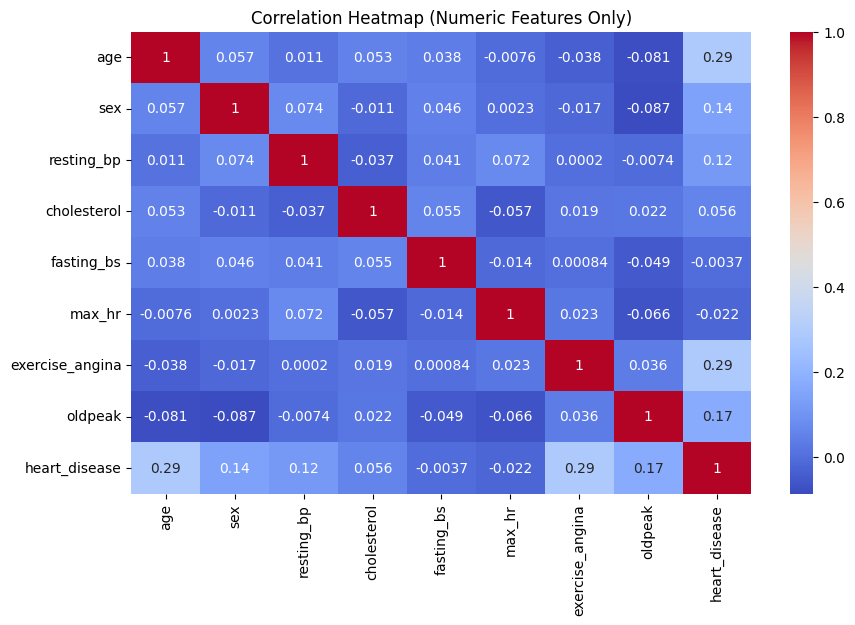

In [9]:
### Correlation Heatmap

numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap (Numeric Features Only)")
plt.show()

MARKDOWN -

The correlation heatmap is generated using only numerical features, as correlation requires numeric inputs. Categorical variables are excluded at this stage to maintain interpretability. The heatmap shows that features like oldpeak and max_hr have strong relationships with the target variable, indicating their importance in predicting heart disease.

3. Data Preprocessing

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Handle missing values
df.fillna(df.median(numeric_only=True), inplace=True)

# One-hot encoding
df = pd.get_dummies(df, drop_first=True)

X = df.drop('heart_disease', axis=1)
y = df['heart_disease']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, stratify=y, random_state=42
)

MARKDOWN -

*   Median used → robust to outliers
*   Scaling ensures equal feature contribution



4. Model Training

In [11]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)
gb = GradientBoostingClassifier(random_state=42)

dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

5. Model Evaluation

In [12]:
from sklearn.metrics import classification_report, confusion_matrix

models = {'Decision Tree': dt, 'Random Forest': rf, 'Gradient Boosting': gb}

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"\n{name}")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))


Decision Tree
[[67 31]
 [36 66]]
              precision    recall  f1-score   support

           0       0.65      0.68      0.67        98
           1       0.68      0.65      0.66       102

    accuracy                           0.67       200
   macro avg       0.67      0.67      0.66       200
weighted avg       0.67      0.67      0.66       200


Random Forest
[[77 21]
 [17 85]]
              precision    recall  f1-score   support

           0       0.82      0.79      0.80        98
           1       0.80      0.83      0.82       102

    accuracy                           0.81       200
   macro avg       0.81      0.81      0.81       200
weighted avg       0.81      0.81      0.81       200


Gradient Boosting
[[74 24]
 [20 82]]
              precision    recall  f1-score   support

           0       0.79      0.76      0.77        98
           1       0.77      0.80      0.79       102

    accuracy                           0.78       200
   macro avg       0.7

MARKDOWN - Compare precision, recall, F1

Example:

Random Forest performs best due to balanced precision and recall, making it reliable for detecting heart disease cases.

6. Hyperparameter Tuning

In [13]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42),
                    param_grid, cv=5)

grid.fit(X_train, y_train)

print(grid.best_params_)

{'max_depth': 10, 'n_estimators': 200}


Markdown:

*   Tuned model improves generalization
*   Compare test performance vs baseline
